# RetailRocket ItemKNN from prepared chronological split


The notebook assumes that the chronological split notebook has already been run.
It loads the prepared RecBole `.train.inter`, `.valid.inter`, and `.test.inter` files,
then trains and evaluates **ItemKNN**.

Please use python version 3.12.10


In [ ]:
!python --version
%pip install -q recbole pandas numpy openpyxl kmeans-pytorch
%pip install -q "ray[tune]"
%pip install -U -q ipywidgets


Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 150.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 128.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.8 MB/s eta 0:00:00


In [ ]:
# Print the active Python interpreter version for environment verification.
import sys

print(sys.version)

# Set a PyTorch environment flag to avoid weights-only loading behaviour that
# may be incompatible with the current workflow.
import os

os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

# Import core external libraries and print versions for reproducibility.
import ray
import recbole

print("ray:", ray.__version__)
print("recbole:", recbole.__version__)

# Add backward-compatible NumPy aliases for libraries expecting deprecated
# type names in newer NumPy versions.
import numpy as np

if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128
if not hasattr(np, "unicode_"):
    np.unicode_ = np.str_

# Import RecBole utilities for model training, loading, and case-study
# recommendation generation.
from recbole.quick_start import run_recbole, load_data_and_model
from recbole.utils.case_study import full_sort_topk

# Import general-purpose utilities used for file handling, tabular data,
# plotting, and archive creation.
from pathlib import Path
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import zipfile

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
ray: 2.55.0
recbole: 1.2.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the dataset name expected by the RecBole pipeline.
DATASET_NAME = "retailrocket_itemknn_chrono"

# Define the source directory containing the prepared split files.
SOURCE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/retailrocket-itemknn-chrono"
)

# Define the local RecBole dataset root and target dataset directory.
RECOBOLE_ROOT = Path("/content/recbole_dataset")
DATASET_DIR = RECOBOLE_ROOT / DATASET_NAME
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Copy each split file from the source directory into the RecBole dataset
# directory.
for split in ["train", "valid", "test"]:
    src = SOURCE_DIR / f"{DATASET_NAME}.{split}.inter"
    dst = DATASET_DIR / f"{DATASET_NAME}.{split}.inter"
    shutil.copy2(src, dst)
    print("Copied:", dst)

# Print the final dataset directory contents for verification.
print("\nFinal structure:")
for p in DATASET_DIR.iterdir():
    print(p)

Copied: /content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.train.inter
Copied: /content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.valid.inter
Copied: /content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.test.inter

Final structure:
/content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.train.inter
/content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.valid.inter
/content/recbole_dataset/retailrocket_itemknn_chrono/retailrocket_itemknn_chrono.test.inter


## 1. Configuration and paths


In [ ]:
# Define the dataset name used throughout the RecBole training pipeline.
DATASET_NAME = "retailrocket_itemknn_chrono"

# Define the fast local runtime directory from which RecBole reads the split
# interaction files during training.
RECOBOLE_ROOT = Path("/content/recbole_dataset")
DATASET_DIR = RECOBOLE_ROOT / DATASET_NAME

# Define the expected train, validation, and test interaction file paths.
train_path = DATASET_DIR / f"{DATASET_NAME}.train.inter"
valid_path = DATASET_DIR / f"{DATASET_NAME}.valid.inter"
test_path = DATASET_DIR / f"{DATASET_NAME}.test.inter"

# Define the persistent Google Drive project root used for storing outputs.
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1")

# Define output directories for tables, figures, and saved model artefacts.
MODEL_OUTPUT_DIR = PROJECT_ROOT / "output" / "retailrocket_itemknn"
TABLE_DIR = MODEL_OUTPUT_DIR / "tables"
FIGURE_DIR = MODEL_OUTPUT_DIR / "figures"
SAVED_DIR = MODEL_OUTPUT_DIR / "saved_models"

# Create the output directories if they do not already exist.
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SAVED_DIR.mkdir(parents=True, exist_ok=True)

# Define explicit save paths for the processed dataset and dataloader
# artefacts so they are written under the output directory.
DATASET_SAVE_PATH = SAVED_DIR / f"{DATASET_NAME}_dataset.pth"
DATALOADER_SAVE_PATH = SAVED_DIR / f"{DATASET_NAME}_dataloaders.pth"

# Print the key input and output paths for verification.
print("Reading split files from:", DATASET_DIR)
print("Saving tables to:", TABLE_DIR)
print("Saving figures to:", FIGURE_DIR)
print("Saving model checkpoints to:", SAVED_DIR)
print("Saving dataset artifact to:", DATASET_SAVE_PATH)
print("Saving dataloader artifact to:", DATALOADER_SAVE_PATH)

Reading split files from: /content/recbole_dataset/retailrocket_itemknn_chrono
Saving tables to: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/tables
Saving figures to: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/figures
Saving model checkpoints to: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models
Saving dataset artifact to: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models/retailrocket_itemknn_chrono_dataset.pth
Saving dataloader artifact to: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models/retailrocket_itemknn_chrono_dataloaders.pth


## 2. Inspect the prepared split files


In [ ]:
# Load the RecBole atomic interaction files for the train, validation, and
# test splits.
train_atomic = pd.read_csv(train_path, sep="\t")
valid_atomic = pd.read_csv(valid_path, sep="\t")
test_atomic = pd.read_csv(test_path, sep="\t")

# Summarise the size and entity coverage of each split.
split_shapes = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_atomic),
            "unique_users": train_atomic["user_id:token"].nunique(),
            "unique_items": train_atomic["item_id:token"].nunique(),
        },
        {
            "split": "valid",
            "rows": len(valid_atomic),
            "unique_users": valid_atomic["user_id:token"].nunique(),
            "unique_items": valid_atomic["item_id:token"].nunique(),
        },
        {
            "split": "test",
            "rows": len(test_atomic),
            "unique_users": test_atomic["user_id:token"].nunique(),
            "unique_items": test_atomic["item_id:token"].nunique(),
        },
    ]
)

# Save the split summary table for reference.
split_shapes.to_csv(
    TABLE_DIR / f"{DATASET_NAME}_recbole_input_summary.csv",
    index=False,
)

# Display the RecBole input summary.
display(split_shapes)

,split,rows,unique_users,unique_items
0,train,1743817,1407580,220008
1,valid,131735,110525,49467
2,test,273872,233086,77054


## 3. Train ItemKNN in RecBole


In [ ]:
# Set the core ItemKNN hyperparameters.
K_NEIGHBORS = 100
SHRINK = 10.0

# Define the RecBole configuration for loading the prepared chronological
# splits, training ItemKNN, and saving the resulting artefacts.
config_dict = {
    "data_path": str(RECOBOLE_ROOT),
    "benchmark_filename": ["train", "valid", "test"],

    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "RATING_FIELD": "rating",
    "TIME_FIELD": "timestamp",
    "field_separator": "\t",
    "load_col": {"inter": ["user_id", "item_id", "rating", "timestamp"]},

    # Configure full-ranking evaluation grouped by user and ordered by time.
    "eval_args": {
        "group_by": "user",
        "order": "TO",
        "mode": "full",
    },

    # Define the evaluation metrics, cut-off points, and validation target.
    "metrics": ["Recall", "MRR", "NDCG", "Hit", "Precision"],
    "topk": [5, 10, 20],
    "valid_metric": "NDCG@10",
    "metric_decimal_place": 4,

    # Set the checkpoint directory for saved RecBole outputs.
    "checkpoint_dir": str(SAVED_DIR),

    # Save the processed dataset object to an explicit output path.
    "save_dataset": True,
    "dataset_save_path": str(DATASET_SAVE_PATH),

    # Save the prepared dataloaders to an explicit output path.
    "save_dataloaders": True,
    "dataloaders_save_path": str(DATALOADER_SAVE_PATH),

    # Configure reproducibility and runtime behaviour.
    "seed": 42,
    "reproducibility": True,
    "worker": 4,
    "eval_batch_size": 4096,
    "use_gpu": False,
    "show_progress": True,

    # Pass ItemKNN-specific hyperparameters.
    "k": K_NEIGHBORS,
    "shrink": SHRINK,
}

# Train and evaluate the ItemKNN model using the prepared dataset.
result = run_recbole(
    model="ItemKNN",
    dataset=DATASET_NAME,
    config_dict=config_dict,
)

# Print the RecBole result dictionary.
print(result)

# Confirm whether the dataset artefact was written successfully.
print("Dataset artifact exists:", DATASET_SAVE_PATH.exists(), DATASET_SAVE_PATH)

# Confirm whether the dataloader artefact was written successfully.
print(
    "Dataloader artifact exists:",
    DATALOADER_SAVE_PATH.exists(),
    DATALOADER_SAVE_PATH,
)

/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

{'best_valid_score': np.float64(0.1018), 'valid_score_bigger': True, 'best_valid_result': OrderedDict({'recall@5': np.float64(0.1263), 'recall@10': np.float64(0.1638), 'recall@20': np.float64(0.2012), 'mrr@5': np.float64(0.0786), 'mrr@10': np.float64(0.0838), 'mrr@20': np.float64(0.0865), 'ndcg@5': np.float64(0.0896), 'ndcg@10': np.float64(0.1018), 'ndcg@20': np.float64(0.1114), 'hit@5': np.float64(0.1297), 'hit@10': np.float64(0.1684), 'hit@20': np.float64(0.2071), 'precision@5': np.float64(0.0261), 'precision@10': np.float64(0.0171), 'precision@20': np.float64(0.0106)}), 'test_result': OrderedDict({'recall@5': np.float64(0.1), 'recall@10': np.float64(0.128), 'recall@20': np.float64(0.1544), 'mrr@5': np.float64(0.0645), 'mrr@10': np.float64(0.0685), 'mrr@20': np.float64(0.0704), 'ndcg@5': np.float64(0.072), 'ndcg@10': np.float64(0.0812), 'ndcg@20': np.float64(0.0881), 'hit@5': np.float64(0.105), 'hit@10': np.float64(0.1346), 'hit@20': np.float64(0.1628), 'precision@5': np.float64(0.02

## 4. Save the test metrics


ItemKNN test metrics


,Precision,Recall,Hit,MRR,NDCG
@5,0.0212,0.1000,0.1050,0.0645,0.0720
@10,0.0137,0.1280,0.1346,0.0685,0.0812
@20,0.0084,0.1544,0.1628,0.0704,0.0881


Saved: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/tables/retailrocket_itemknn_chrono_itemknn_test_metrics.csv


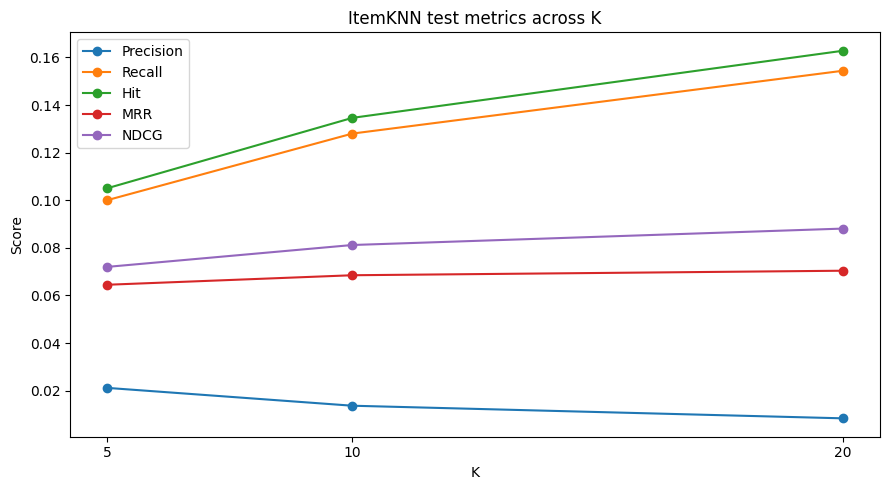

Saved graph: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/figures/retailrocket_itemknn_chrono_itemknn_test_metrics_curve.png


In [ ]:
# Extract the test-set evaluation metrics returned by RecBole.
test_result = result["test_result"]

# Organise the main ranking metrics into a compact comparison table across
# the requested cut-off values.
itemknn_results = pd.DataFrame(
    {
        "Precision": [
            test_result.get("precision@5"),
            test_result.get("precision@10"),
            test_result.get("precision@20"),
        ],
        "Recall": [
            test_result.get("recall@5"),
            test_result.get("recall@10"),
            test_result.get("recall@20"),
        ],
        "Hit": [
            test_result.get("hit@5"),
            test_result.get("hit@10"),
            test_result.get("hit@20"),
        ],
        "MRR": [
            test_result.get("mrr@5"),
            test_result.get("mrr@10"),
            test_result.get("mrr@20"),
        ],
        "NDCG": [
            test_result.get("ndcg@5"),
            test_result.get("ndcg@10"),
            test_result.get("ndcg@20"),
        ],
    },
    index=["@5", "@10", "@20"],
)

# Define the CSV output path for the ItemKNN test metrics table.
metrics_csv = TABLE_DIR / f"{DATASET_NAME}_itemknn_test_metrics.csv"

# Save the metrics table for later reporting and reuse.
itemknn_results.to_csv(metrics_csv)

# Display the formatted metrics table and confirm the save location.
print("ItemKNN test metrics")
display(itemknn_results.style.format("{:.4f}"))
print("Saved:", metrics_csv)

# Create a plotting copy with explicit K values for the x-axis.
metrics_plot_df = itemknn_results.copy()
metrics_plot_df["K"] = [5, 10, 20]

# Plot each evaluation metric across the selected K values.
plt.figure(figsize=(9, 5))
for col in ["Precision", "Recall", "Hit", "MRR", "NDCG"]:
    plt.plot(metrics_plot_df["K"], metrics_plot_df[col], marker="o", label=col)

# Add axis labels, title, tick marks, and legend for readability.
plt.xlabel("K")
plt.ylabel("Score")
plt.title("ItemKNN test metrics across K")
plt.xticks([5, 10, 20])
plt.legend()
plt.tight_layout()

# Save the metric comparison figure.
metrics_fig_path = FIGURE_DIR / f"{DATASET_NAME}_itemknn_test_metrics_curve.png"
plt.savefig(metrics_fig_path, bbox_inches="tight")
plt.show()

# Confirm the figure output path.
print("Saved graph:", metrics_fig_path)

## 5. Reload the saved model


In [ ]:
# Locate all saved ItemKNN checkpoint files and sort them by modification time.
model_checkpoints = sorted(SAVED_DIR.glob("ItemKNN-*.pth"), key=os.path.getmtime)

# Stop execution if no saved checkpoint is available.
if not model_checkpoints:
    raise FileNotFoundError(f"No ItemKNN model checkpoint found in {SAVED_DIR}")

# Select the most recently modified checkpoint for reloading.
latest_model = model_checkpoints[-1]
print("Reloading model checkpoint:", latest_model)

# Reload the trained model together with the associated configuration,
# dataset, and dataloaders.
config, model, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file=str(latest_model)
)

# Print basic metadata about the reloaded training artefacts.
print("Loaded dataset:", config["dataset"])
print("Users:", dataset.user_num)
print("Items:", dataset.item_num)
print("Dataset artifact:", DATASET_SAVE_PATH)
print("Dataloader artifact:", DATALOADER_SAVE_PATH)

Reloading model checkpoint: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models/ItemKNN-Apr-15-2026_14-17-45.pth


/usr/local/lib/python3.12/dist-packages/recbole/quick_start/quick_start.py:250: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  checkpoint = torch.load(model_file)
/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.12/dist-packages/recbole/data/dataset/dataset

Loaded dataset: retailrocket_itemknn_chrono
Users: 1407581
Items: 220009
Dataset artifact: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models/retailrocket_itemknn_chrono_dataset.pth
Dataloader artifact: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/saved_models/retailrocket_itemknn_chrono_dataloaders.pth


## 6. Show top-10 recommendations for one sample user


Top-10 recommendations for sample user 0


,rank,item_id,score
0,1,203022,0.066310
1,2,453814,0.063198
2,3,163474,0.060172
3,4,124804,0.054802
4,5,314688,0.051558
5,6,185687,0.049038
6,7,339087,0.045479
7,8,199452,0.040913
8,9,365536,0.039403
9,10,8692,0.037401


Saved: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/tables/retailrocket_itemknn_chrono_sample_user_top10_recommendations.csv


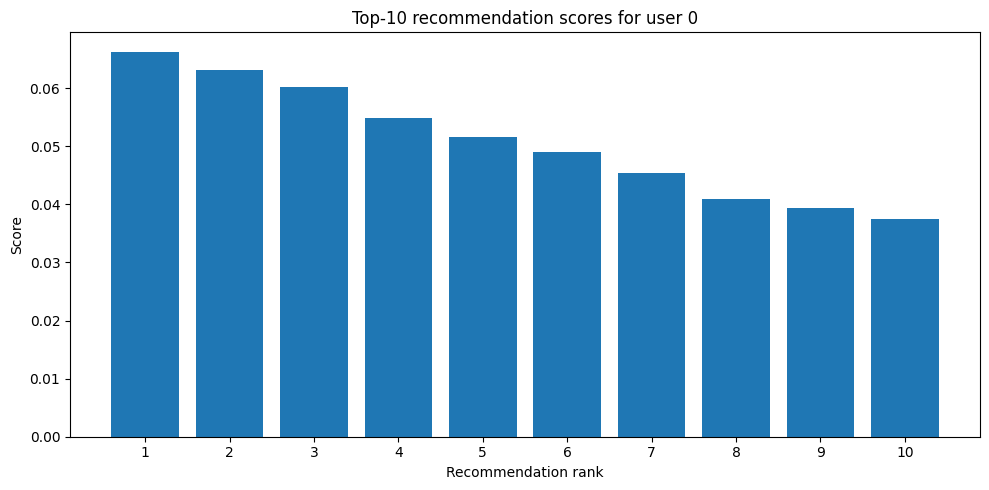

Saved graph: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/figures/retailrocket_itemknn_chrono_sample_user_top10_scores.png
Saved zip: /content/drive/MyDrive/Colab Notebooks/Advanced AI Year 3/Task 1/output/retailrocket_itemknn/retailrocket_itemknn_chrono_output_bundle.zip


In [ ]:
# Select a sample user token from the training interactions.
sample_user_token = str(train_atomic["user_id:token"].iloc[0])

# Convert the external user token to the internal dataset user identifier.
sample_user_id = dataset.token2id(dataset.uid_field, [sample_user_token])[0]

# Generate top-10 full-sort recommendations for the selected user.
topk_scores, topk_iids = full_sort_topk(
    [sample_user_id],
    model,
    test_data,
    k=10,
    device=config["device"],
)

# Convert the recommended internal item identifiers back to item tokens.
recommended_item_tokens = dataset.id2token(
    dataset.iid_field,
    topk_iids.cpu().numpy()[0],
)

# Build a tabular view of the recommendation ranks and scores.
recommendation_df = pd.DataFrame(
    {
        "rank": np.arange(1, len(recommended_item_tokens) + 1),
        "item_id": recommended_item_tokens,
        "score": topk_scores.cpu().detach().numpy()[0],
    }
)

# Define the CSV output path for the sample user's recommendations.
rec_csv = TABLE_DIR / f"{DATASET_NAME}_sample_user_top10_recommendations.csv"

# Save the recommendation table for later inspection.
recommendation_df.to_csv(rec_csv, index=False)

# Display the sample user's top-10 recommendations and confirm the save path.
print(f"Top-10 recommendations for sample user {sample_user_token}")
display(recommendation_df)
print("Saved:", rec_csv)

# Plot the recommendation scores by rank.
plt.figure(figsize=(10, 5))
plt.bar(recommendation_df["rank"].astype(str), recommendation_df["score"])
plt.xlabel("Recommendation rank")
plt.ylabel("Score")
plt.title(f"Top-10 recommendation scores for user {sample_user_token}")
plt.tight_layout()

# Define the figure output path for the recommendation score chart.
rec_fig_path = FIGURE_DIR / f"{DATASET_NAME}_sample_user_top10_scores.png"

# Save and display the recommendation score figure.
plt.savefig(rec_fig_path, bbox_inches="tight")
plt.show()

# Confirm the figure save path.
print("Saved graph:", rec_fig_path)

# Define the ZIP output path for bundling all generated outputs.
zip_path = MODEL_OUTPUT_DIR / f"{DATASET_NAME}_output_bundle.zip"

# Archive the output directory contents, excluding the ZIP file itself.
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in MODEL_OUTPUT_DIR.rglob("*"):
        if p.is_file() and p != zip_path:
            zf.write(p, arcname=p.relative_to(MODEL_OUTPUT_DIR))

# Confirm the ZIP bundle save path.
print("Saved zip:", zip_path)